In [1]:
import pandas as pd
df = pd.read_excel("Amazon_Sales.xlsx", sheet_name='Amazon')
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [2]:
print(df.shape)
print(df.dtypes)
df.describe()

(100000, 20)
OrderID                  object
OrderDate        datetime64[ns]
CustomerID               object
CustomerName             object
ProductID                object
ProductName              object
Category                 object
Brand                    object
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod            object
OrderStatus              object
City                     object
State                    object
Country                  object
SellerID                 object
dtype: object


,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [3]:
if 'Profit' not in df.columns:
    margins = {'Electronics': 0.15, 'Sports & Outdoors': 0.12, 'Books': 0.18, 'Home & Kitchen': 0.10, 'Toys & Games': 0.14, 'Clothing': 0.04}
    df['Profit'] = df.apply(lambda row: row['TotalAmount'] * margins.get(row['Category'], 0.10), axis=1)

kpis = pd.DataFrame({
    'Metric': ['Total Sales', 'Total Profit', 'Total Orders', 'Average Sales', 'Average Profit', 'Maximum Sales', 'Minimum Sales'],
    'Value': [df['TotalAmount'].sum(), df['Profit'].sum(), df['OrderID'].nunique(), df['TotalAmount'].mean(), df['Profit'].mean(), df['TotalAmount'].max(), df['TotalAmount'].min()]
})
kpis

,Metric,Value
0,Total Sales,9.182565e+07
1,Total Profit,1.118310e+07
2,Total Orders,1.000000e+05
3,Average Sales,9.182565e+02
4,Average Profit,1.118310e+02
5,Maximum Sales,3.534980e+03
6,Minimum Sales,4.270000e+00


In [4]:
state_sales = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False).reset_index()
state_sales

,State,TotalAmount
0,TX,22862540.54
1,CA,18231196.79
2,NC,4747701.73
3,WA,4660962.17
4,PA,4650673.88
5,CO,4638498.97
6,IL,4632847.44
7,OH,4615442.32
8,IN,4609048.43
9,FL,4597177.27


In [5]:
category_sales = df.groupby('Category')['TotalAmount'].sum().reset_index()
category_sales

,Category,TotalAmount
0,Books,15261837.01
1,Clothing,15253397.50
2,Electronics,15584217.18
3,Home & Kitchen,15163939.36
4,Sports & Outdoors,15345571.88
5,Toys & Games,15216684.99


In [6]:
sub_col = 'Sub-Category' if 'Sub-Category' in df.columns else 'Brand'
sub_category_sales = df.groupby(sub_col)['TotalAmount'].sum().reset_index()
sub_category_sales

,Brand,TotalAmount
0,Apex,9147604.72
1,BrightLux,9056816.11
2,CoreTech,9343720.59
3,FitLife,9061444.68
4,HomeEase,9045092.83
5,KiddoFun,9324749.55
6,NexPro,9078824.97
7,ReadMore,9278406.63
8,UrbanStyle,9249027.45
9,Zenith,9239960.39


In [7]:
top_5_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5).reset_index()
top_5_customers

,CustomerName,TotalAmount
0,Pooja Kapoor,547832.64
1,Vihaan Singh,526675.89
2,Pooja Singh,516451.45
3,Kabir Joshi,515361.68
4,Aditya Gupta,515005.09


In [8]:
product_quantity = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).reset_index()
product_quantity

,ProductName,Quantity
0,LED Desk Lamp,6344
1,Water Bottle,6275
2,Memory Card 128GB,6240
3,Router,6202
4,Board Game,6200
5,Microphone,6196
6,Gaming Mouse,6170
7,Electric Kettle,6165
8,Mechanical Keyboard,6161
9,Vacuum Cleaner,6139


In [9]:
pay_col = 'PaymentMode' if 'PaymentMode' in df.columns else 'PaymentMethod'
payment_orders = df.groupby(pay_col)['OrderID'].nunique().reset_index()
payment_orders

,PaymentMethod,OrderID
0,Amazon Pay,15017
1,Cash on Delivery,4928
2,Credit Card,35038
3,Debit Card,20024
4,Net Banking,9927
5,UPI,15066


In [10]:
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
monthly_sales = df.groupby('OrderMonth')['TotalAmount'].sum().reset_index()
monthly_sales

,OrderMonth,TotalAmount
0,2020-01,1637069.40
1,2020-02,1339388.21
2,2020-03,1587125.66
3,2020-04,1588347.29
4,2020-05,1533834.17
5,2020-06,1500269.29
6,2020-07,1552981.94
7,2020-08,1640874.93
8,2020-09,1554682.21
9,2020-10,1515403.62


In [11]:
state_category_sales = df.groupby(['State', 'Category'])['TotalAmount'].sum().reset_index()
state_category_sales

,State,Category,TotalAmount
0,AZ,Books,793211.33
1,AZ,Clothing,691249.82
2,AZ,Electronics,747955.37
3,AZ,Home & Kitchen,737616.34
4,AZ,Sports & Outdoors,694318.06
...,...,...,...
73,WA,Clothing,747668.70
74,WA,Electronics,879580.90
75,WA,Home & Kitchen,809448.28
76,WA,Sports & Outdoors,807282.60


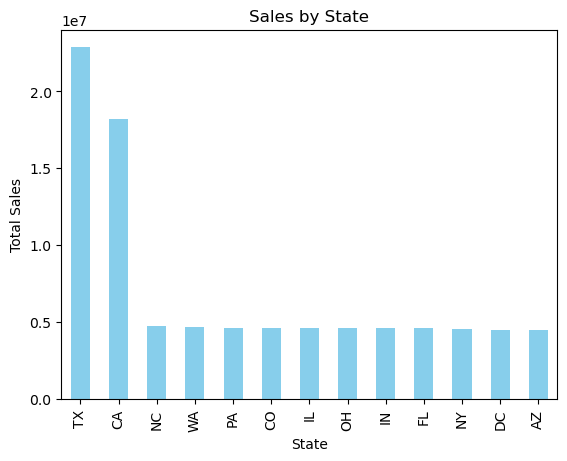

In [12]:
import matplotlib.pyplot as plt
state_sales.plot(kind='bar', x='State', y='TotalAmount', legend=False, color='skyblue')
plt.title('Sales by State')
plt.ylabel('Total Sales')
plt.show()

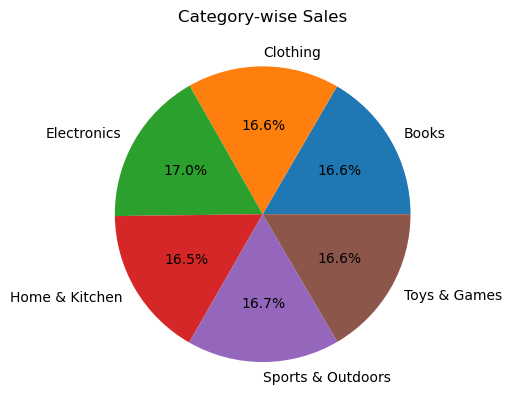

In [13]:
category_sales.set_index('Category').plot(kind='pie', y='TotalAmount', autopct='%1.1f%%', legend=False)
plt.title('Category-wise Sales')
plt.ylabel('')
plt.show()

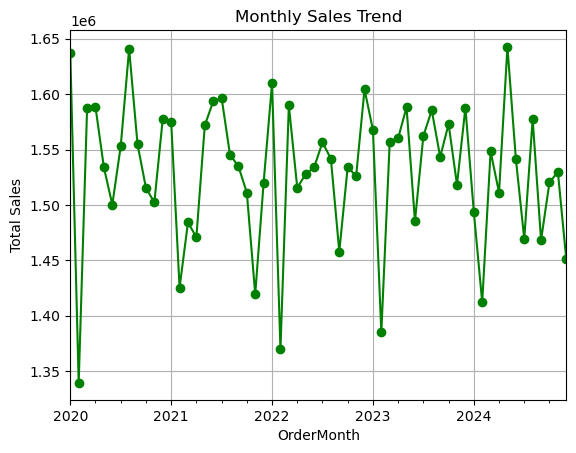

In [14]:
monthly_sales_plot = df.groupby('OrderMonth')['TotalAmount'].sum()
monthly_sales_plot.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

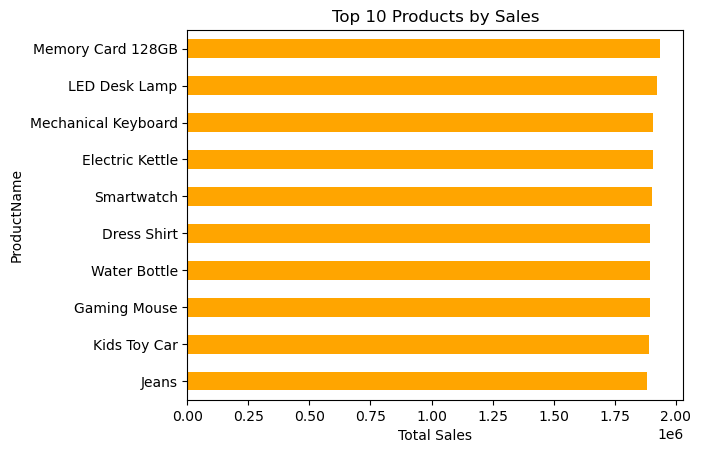

In [15]:
top_10_products = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
top_10_products.sort_values(ascending=True).plot(kind='barh', color='orange')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.show()